#### By: Peyman Shahidi
#### Created: Aug 21, 2026

<br>

Execution mode of the middle step in the local block of Proposition 1, as a function of the predecessor's and the middle step's success probabilities.

Panel (a):


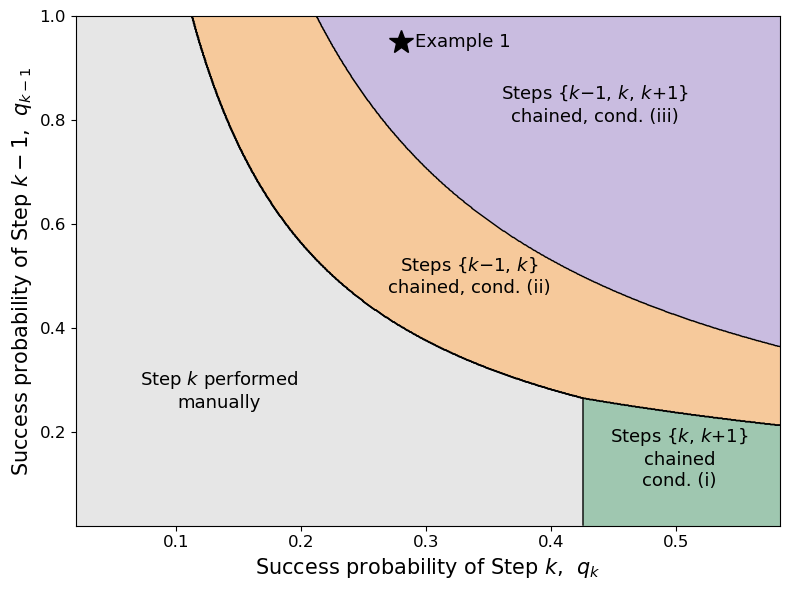

  manual               optimal on  42.5% of the grid
  chain {k,k+1}        optimal on   6.2% of the grid
  chain {k-1,k,k+1}    optimal on  28.3% of the grid
  chain {k-1,k}        optimal on  23.0% of the grid
Panel (b):


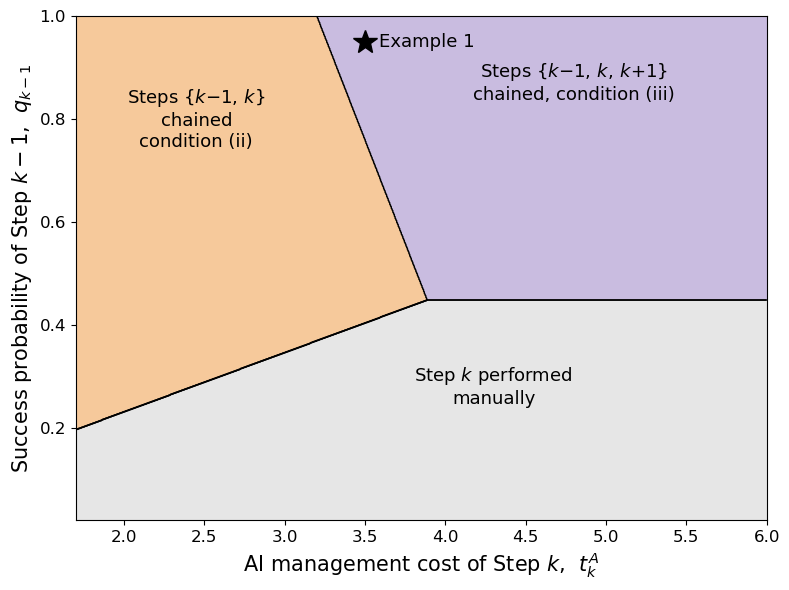

  manual               optimal on  37.1% of the grid
  chain {k,k+1}        optimal on   0.0% of the grid
  chain {k-1,k,k+1}    optimal on  32.2% of the grid
  chain {k-1,k}        optimal on  30.7% of the grid


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import os

main_folder_path = ".."
output_plot_path = f"{main_folder_path}/writeup/plots"
os.makedirs(output_plot_path, exist_ok=True)

# How the cost-minimizing arrangement of the block {k-1, k, k+1} executes the middle
# step k, over two slices of the parameter space. Everything not on an axis is fixed at
# the values of Example 1 of Section 4.1: an expensive but AI-reliable predecessor, an
# AI-hard middle step on which the human holds the comparative advantage throughout,
# and an AI-easy endpoint executed as a standalone augmented step.
tM_p, tA_p = 25.0, 25.0          # step k-1: manual cost, AI management cost
tM_k, tA_k0, qk0 = 6.0, 3.5, 0.28  # step k  : manual cost, AI management cost, success probability
tM_n, tA_n, q_n = 8.0, 4.0, 0.9  # step k+1: manual cost, AI management cost, success probability

v_n = min(tM_n, tA_n / q_n)      # standalone cost of the endpoint

LABEL_FS, TICK_FS, REGION_FS = 15, 12, 13
COLORS = ["#e6e6e6", "#9fc7b0", "#c9bce0", "#f6c99b"]   # manual, (i), (ii), (iii)
# Colors follow the TikZ figures: manual grey, automated green, augmented orange. In region (i)
# step k is automated inside the chain; in region (ii) it terminates the chain and is augmented.
NAMES  = ["manual", "chain {k,k+1}", "chain {k-1,k,k+1}", "chain {k-1,k}"]


def arrangement_costs(QP, QK, TA_K):
    """Cost of each feasible arrangement of the block, given grids of parameters."""
    v_p = np.minimum(tM_p, tA_p / QP)
    return np.stack([
        v_p + tM_k + v_n,                 # step k manual, neighbours on their own
        v_p + tA_n / (QK * q_n),          # steps k, k+1 chained        -> condition (i)
        tA_n / (QP * QK * q_n),           # steps k-1, k, k+1 chained   -> condition (iii)
        TA_K / (QP * QK) + v_n,           # steps k-1, k chained        -> condition (ii)
    ])


def region_plot(X, Y, best, xlabel, ylabel, labels, star, fname):
    plt.figure(figsize=(8, 6))
    plt.pcolormesh(X, Y, best, cmap=ListedColormap(COLORS), vmin=-0.5, vmax=3.5, shading="auto")
    plt.contour(X, Y, best, levels=[0.5, 1.5, 2.5], colors="black", linewidths=1)
    for (x, y, text) in labels:
        plt.text(x, y, text, ha="center", va="center", fontsize=REGION_FS)
    if star is not None:
        plt.plot(*star, marker="*", markersize=18, color="black")
        plt.text(star[0] + 0.02 * (X.max() - X.min()), star[1], "Example 1", fontsize=REGION_FS, va="center")
    plt.xlabel(xlabel, fontsize=LABEL_FS)
    plt.ylabel(ylabel, fontsize=LABEL_FS)
    plt.xlim(X.min(), X.max())
    plt.ylim(Y.min(), Y.max())
    plt.tick_params(labelsize=TICK_FS)
    plt.tight_layout()
    plt.savefig(f"{output_plot_path}/{fname}", dpi=300)
    plt.show()
    for i, n in enumerate(NAMES):
        print(f"  {n:20s} optimal on {100*(best == i).mean():5.1f}% of the grid")


# ---------- Panel (a): the two success probabilities, with tA_k fixed ----------
# The human holds the comparative advantage on step k whenever tM_k < tA_k / q_k, that is
# for q_k below tA_k / tM_k, which is where the horizontal axis stops.
qk = np.linspace(0.02, tA_k0 / tM_k, 900)
qp = np.linspace(0.02, 1.0, 900)
QK, QP = np.meshgrid(qk, qp)
best_a = np.argmin(arrangement_costs(QP, QK, tA_k0), axis=0)

print("Panel (a):")
region_plot(
    QK, QP, best_a,
    r"Success probability of Step $k$,  $q_k$",
    r"Success probability of Step $k-1$,  $q_{k-1}$",
    [(0.135, 0.28, "Step $k$ performed\nmanually"),
     (0.503, 0.15, "Steps $\\{k,\\, k{+}1\\}$\nchained\ncond. (i)"),
     (0.435, 0.83, "Steps $\\{k{-}1,\\, k,\\, k{+}1\\}$\nchained, cond. (iii)"),
     (0.335, 0.50, "Steps $\\{k{-}1,\\, k\\}$\nchained, cond. (ii)")],
    (qk0, 0.95), "ca_regions_reliability.png",
)

# ---------- Panel (b): step k's own AI management cost, with q_k fixed ----------
# Below tA_k = q_k * tM_k the AI holds the comparative advantage on step k in isolation,
# so the horizontal axis starts there.
ta = np.linspace(qk0 * tM_k + 0.02, 6.0, 900)
TA, QP2 = np.meshgrid(ta, qp)
best_b = np.argmin(arrangement_costs(QP2, qk0, TA), axis=0)

print("Panel (b):")
region_plot(
    TA, QP2, best_b,
    r"AI management cost of Step $k$,  $t^A_k$",
    r"Success probability of Step $k-1$,  $q_{k-1}$",
    [(4.3, 0.28, "Step $k$ performed\nmanually"),
     (2.45, 0.80, "Steps $\\{k{-}1,\\, k\\}$\nchained\ncondition (ii)"),
     (4.8, 0.87, "Steps $\\{k{-}1,\\, k,\\, k{+}1\\}$\nchained, condition (iii)")],
    (tA_k0, 0.95), "ca_regions_mgmtcost.png",
)


  manual               fills  45.3% of the wedge
  chain {k,k+1}        fills   4.6% of the wedge
  chain {k-1,k,k+1}    fills  29.7% of the wedge
  chain {k-1,k}        fills  20.4% of the wedge


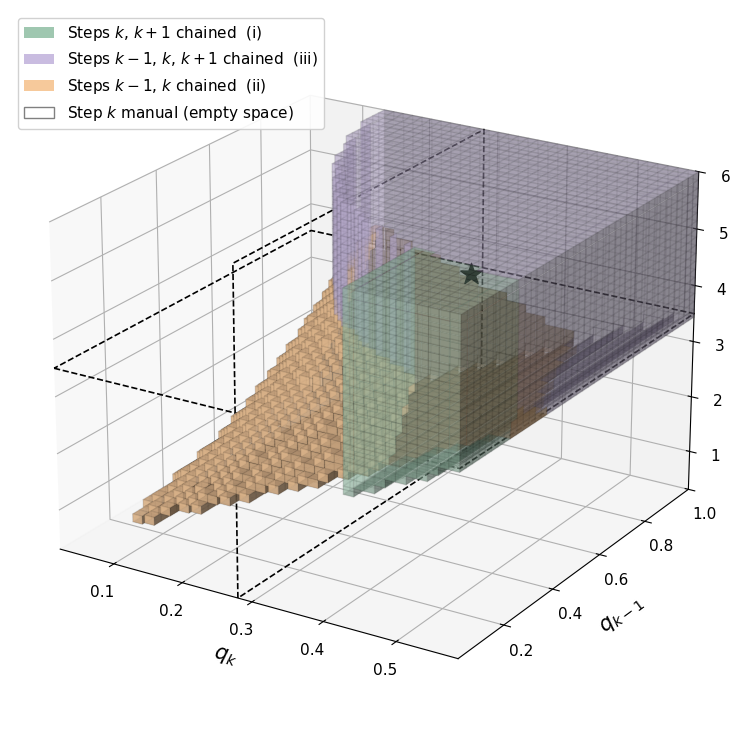

In [2]:
# ---------- Exercise: the two panels above are slices of one three-dimensional map ----------
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.patches import Patch

# Grid over (q_k, q_{k-1}, tA_k). The human holds the comparative advantage on step k only
# where tA_k > q_k * tM_k, so the admissible domain is the wedge above that plane.
nx = ny = nz = 40
xe = np.linspace(0.02, tA_k0 / tM_k, nx + 1)     # q_k
ye = np.linspace(0.02, 1.0, ny + 1)              # q_{k-1}
ze = np.linspace(0.30, 6.0, nz + 1)              # tA_k
mid = lambda e: (e[:-1] + e[1:]) / 2
XC, YC, ZC = np.meshgrid(mid(xe), mid(ye), mid(ze), indexing="ij")

best3 = np.argmin(arrangement_costs(YC, XC, ZC), axis=0)
admissible = ZC > XC * tM_k                      # human-advantaged part of the grid
for i, n in enumerate(NAMES):
    print(f"  {n:20s} fills {100*((best3 == i) & admissible).sum() / admissible.sum():5.1f}% of the wedge")

# Draw only the three AI regions; the manual region is the empty space between them.
draw = admissible & (best3 > 0)
facecolors = np.zeros(best3.shape + (4,))
for i, c in enumerate(COLORS):
    rgb = plt.matplotlib.colors.to_rgb(c)
    facecolors[best3 == i] = (*rgb, 0.42 if i != 3 else 0.75)

X, Y, Z = np.meshgrid(xe, ye, ze, indexing="ij")
fig = plt.figure(figsize=(9, 7.5))
ax = fig.add_subplot(projection="3d")
ax.voxels(X, Y, Z, draw, facecolors=facecolors, edgecolors=(0, 0, 0, 0.06))

# the two slices drawn as panels (a) and (b) above
ax.plot([xe[0], xe[-1], xe[-1], xe[0], xe[0]], [ye[0], ye[0], ye[-1], ye[-1], ye[0]],
        [tA_k0] * 5, color="black", lw=1.2, ls="--")
ax.plot([qk0] * 5, [ye[0], ye[0], ye[-1], ye[-1], ye[0]],
        [ze[0], ze[-1], ze[-1], ze[0], ze[0]], color="black", lw=1.2, ls="--")
ax.scatter([qk0], [0.95], [tA_k0], color="black", marker="*", s=260, depthshade=False)

ax.set_xlabel(r"$q_k$", fontsize=LABEL_FS, labelpad=8)
ax.set_ylabel(r"$q_{k-1}$", fontsize=LABEL_FS, labelpad=8)
ax.set_zlabel(r"$t^A_k$", fontsize=LABEL_FS, labelpad=8)
ax.set_xlim(xe[0], xe[-1]); ax.set_ylim(ye[0], ye[-1]); ax.set_zlim(ze[0], ze[-1])
ax.tick_params(labelsize=TICK_FS - 1)
ax.view_init(elev=22, azim=-58)
ax.legend(handles=[Patch(facecolor=COLORS[1], label="Steps $k$, $k+1$ chained  (i)"),
                   Patch(facecolor=COLORS[2], label="Steps $k-1$, $k$, $k+1$ chained  (iii)"),
                   Patch(facecolor=COLORS[3], label="Steps $k-1$, $k$ chained  (ii)"),
                   Patch(facecolor="white", edgecolor="grey", label="Step $k$ manual (empty space)")],
          loc="upper left", fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.savefig(f"{output_plot_path}/ca_regions_3d.png", dpi=300)
plt.show()


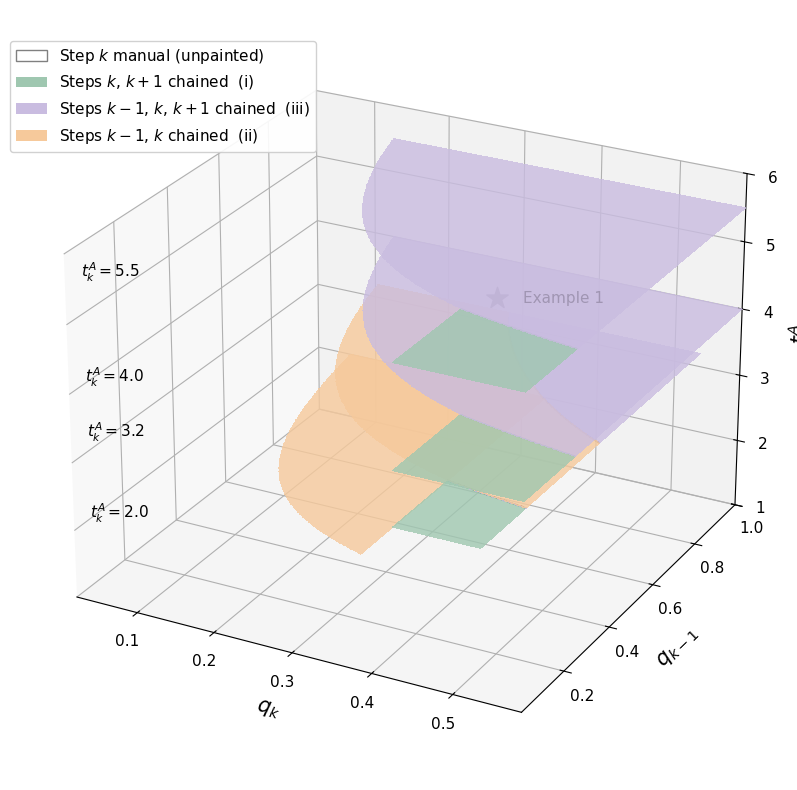

In [3]:
# ---------- Exercise, second take: the same map as a stack of slices ----------
from matplotlib.patches import Patch

# Panels (a) and (b) are two cuts through one three-dimensional region map over
# (q_k, q_{k-1}, tA_k). Stacking horizontal cuts shows how the picture changes with the
# middle step's own AI management cost. The wedge tA_k > q_k * tM_k, outside which AI
# holds the comparative advantage on step k in isolation, is blanked out on each slice.
qk_s = np.linspace(0.02, tA_k0 / tM_k, 400)
qp_s = np.linspace(0.02, 1.0, 400)
QKs, QPs = np.meshgrid(qk_s, qp_s)

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(projection="3d")

slices = [2.0, 3.2, 4.0, 5.5]
for ta in slices:
    b = np.argmin(arrangement_costs(QPs, QKs, ta), axis=0).astype(float)
    b[QKs * tM_k >= ta] = np.nan                       # outside the human-advantaged wedge
    b[b == 0] = np.nan                                 # leave the manual region unpainted
    ax.contourf(QKs, QPs, b, zdir="z", offset=ta, levels=[0.5, 1.5, 2.5, 3.5],
                colors=COLORS[1:], alpha=0.8)
    ax.contour(QKs, QPs, b, zdir="z", offset=ta, levels=[1.5, 2.5],
               colors="black", linewidths=0.8)
    ax.text(0.03, 0.05, ta + 0.12, f"$t^A_k = {ta}$", fontsize=11)

ax.scatter([qk0], [0.95], [tA_k0 + 0.06], color="black", marker="*", s=260, depthshade=False, zorder=10)
ax.text(qk0 + 0.035, 0.95, tA_k0 + 0.06, "Example 1", fontsize=11, zorder=10)

ax.set_xlabel(r"$q_k$", fontsize=LABEL_FS, labelpad=8)
ax.set_ylabel(r"$q_{k-1}$", fontsize=LABEL_FS, labelpad=8)
ax.set_zlabel(r"$t^A_k$", fontsize=LABEL_FS, labelpad=6)
ax.set_xlim(qk_s[0], qk_s[-1]); ax.set_ylim(qp_s[0], qp_s[-1]); ax.set_zlim(1.0, 6.0)
ax.tick_params(labelsize=TICK_FS - 1)
ax.view_init(elev=25, azim=-62)
ax.legend(handles=[Patch(facecolor="white", edgecolor="grey", label="Step $k$ manual (unpainted)"),
                   Patch(facecolor=COLORS[1], label="Steps $k$, $k+1$ chained  (i)"),
                   Patch(facecolor=COLORS[2], label="Steps $k-1$, $k$, $k+1$ chained  (iii)"),
                   Patch(facecolor=COLORS[3], label="Steps $k-1$, $k$ chained  (ii)")],
          loc="upper left", bbox_to_anchor=(-0.02, 0.97), fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.savefig(f"{output_plot_path}/ca_regions_3d_slices.png", dpi=300)
plt.show()
